# 39) Kesikli Uniform Dağılımı
Kesikli Uniform Dağılım, sonlu sayıda olası değerin **hepsinin eşit olasılıkla** gerçekleştiği kesikli bir olasılık dağılımıdır. "Uniform" (eşdağılımlı) ismi tam olarak bunu anlatıyor, hiçbir değer diğerinden daha olası değildir.

## En Basit Örnek: Zar Atışı
Adil bir zarda 1'den 6'ya kadar her değer eşit olasılıkla (1/6) gelir. Aslında Rassal Değişken konusunda zar örneğini işlerken bu dağılımı zaten kullanmıştık, sadece resmi adını koymamıştık.

## Olasılık Kütle Fonksiyonu (PMF)
Eğer *n* tane eşit olasılıklı değer varsa, her birinin olasılığı:
$$P(X=x) = \frac{1}{n}$$

## Beklenen Değer ve Varyans
$a$'dan $b$'ye kadar ardışık tam sayılardan oluşan bir kesikli uniform dağılım için:
$$E(X) = \frac{a+b}{2} \qquad Var(X) = \frac{(b-a+1)^2 - 1}{12}$$

*Örnek (zar):* $a=1$, $b=6$ olduğu için $E(X) = \frac{1+6}{2} = 3.5$ Konu 31'te (Beklenen Değer) bulduğumuz sonuçla birebir örtüşüyor.

## Diğer Dağılımlardan Farkı
Bernoulli, Binom ve Poisson dağılımlarında bazı sonuçlar diğerlerinden **daha olasıydı** (örneğin Binom'da PMF grafiğinin ortası tepe yapıyordu, uçlar daha az olasıydı). Kesikli Uniform'da ise **hiçbir sonuç diğerinden daha olası değildir**. PMF grafiği düz, yatay bir çizgi gibi görünür, hiç tepe noktası yoktur.

## Kullanım Alanları
- Adil bir zarın atılması
- Bir kartın rastgele çekilmesi (her kartın gelme olasılığı eşit)
- Bir çekilişte her katılımcının eşit kazanma şansına sahip olması
- Rastgele bir tam sayı üretme (örn: 1-100 arası eşit olasılıkla)

Teorik Beklenen Değer: 3.5
SciPy'ın hesapladığı ortalama: 3.5


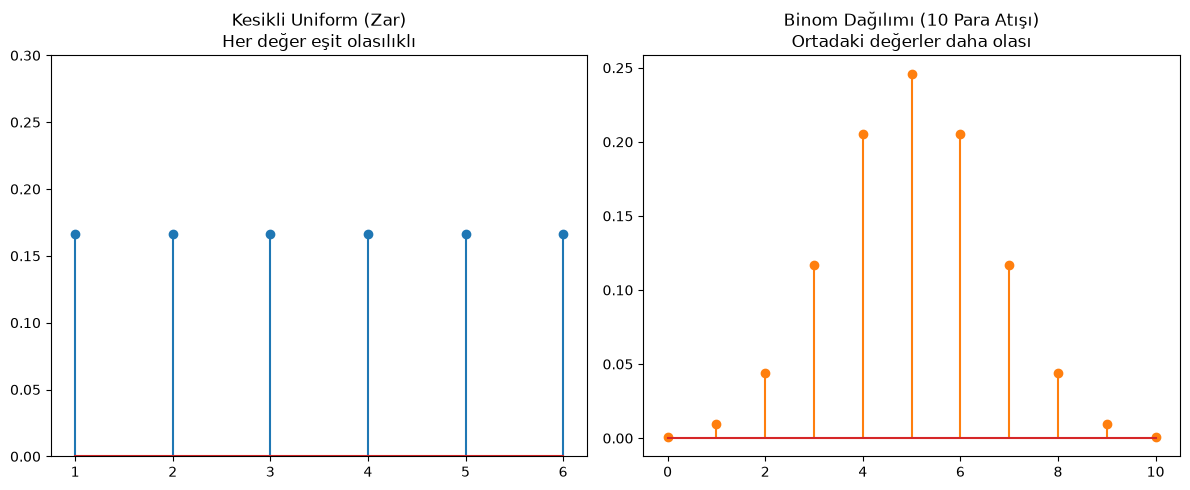

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Kesikli Uniform: Zar Örneği ---
# scipy'de randint(low, high) kullanılır — dikkat: high değeri DAHİL DEĞİLDİR, 
# bu yüzden 6'yı dahil etmek için high=7 yazılır
zar_degerleri = np.arange(1, 7)
olasiliklar_uniform = stats.randint.pmf(zar_degerleri, low=1, high=7)

# Teorik Beklenen Değer (formülden)
a, b = 1, 6
teorik_E = (a + b) / 2
print(f"Teorik Beklenen Değer: {teorik_E}")

# scipy'nin kendi hesapladığı ortalama ile karşılaştıralım
scipy_ortalama = stats.randint.mean(low=1, high=7)
print(f"SciPy'ın hesapladığı ortalama: {scipy_ortalama}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Uniform PMF (düz)
ax1.stem(zar_degerleri, olasiliklar_uniform)
ax1.set_title("Kesikli Uniform (Zar)\nHer değer eşit olasılıklı")
ax1.set_ylim(0, 0.3)

# Binom PMF (çan şekilli, karşılaştırma için)
n, p = 10, 0.5
x_binom = np.arange(0, n+1)
y_binom = stats.binom.pmf(x_binom, n, p)
ax2.stem(x_binom, y_binom, linefmt='C1-', markerfmt='C1o')
ax2.set_title("Binom Dağılımı (10 Para Atışı)\nOrtadaki değerler daha olası")

plt.tight_layout()
plt.show()

### Sonuç
Yukarıda modellediğimiz kesikli uniform dağılımında gördüğümüz üzere zar'ın her bir değerinin eşit olasılıkta gelebileceğini görüyoruz. Beklenen değer ise, bu zar atışını uzunca bir süre devam ettirseydik elde ettiğimiz değerlerin ortalamasının SciPy 3.5 olarak hesaplıyor ki bu bizim formülden elde ettiğimiz değer ile aynı. Bu beklenen değerin, bir zar atışında gelme olasılığı olmasa da uzun vadede elde edinilen değerlerin ortalamasını aldığımız için sonuç olası değerlerden farklı çıkabiliyor.